In [7]:
# TRAINING

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Sample random (x, y) points inside the unit square [0,1] x [0,1]
N_interior = 10000

# Boundary points
N_boundary = 1000
t = torch.linspace(0, 1, N_boundary, device=device).unsqueeze(1)

x_top = t;  y_top = torch.ones(N_boundary, 1, device=device)
x_bottom = t;  y_bottom = torch.zeros(N_boundary, 1, device=device)
x_left = torch.zeros(N_boundary, 1, device=device);  y_left = t
x_right = torch.ones(N_boundary, 1, device=device);  y_right = t

class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
        nn.Linear(2, 64),
        nn.Tanh(),
        nn.Linear(64, 64),
        nn.Tanh(),
        nn.Linear(64, 64),
        nn.Tanh(),
        nn.Linear(64, 64),
        nn.Tanh(),
        nn.Linear(64, 3)
        )

    def forward(self, x, y):
        xy = torch.cat([x, y], dim=1)
        out = self.net(xy)
        return out[:, 0:1], out[:, 1:2], out[:, 2:3]

model = PINN().to(device)
print(model)

def compute_physics_loss(model, x, y, Re=100):
    x = x.requires_grad_(True)
    y = y.requires_grad_(True)

    # Forward pass
    u, v, p = model(x, y)

    # First derivatives
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    v_x = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_y = torch.autograd.grad(v, y, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    p_x = torch.autograd.grad(p, x, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    p_y = torch.autograd.grad(p, y, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    
    # Second derivatives
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, x, grad_outputs=torch.ones_like(v_x), create_graph=True)[0]
    v_yy = torch.autograd.grad(v_y, y, grad_outputs=torch.ones_like(v_y), create_graph=True)[0]
    
    # Navier-Stokes residuals
    continuity = u_x + v_y
    momentum_x = u*u_x + v*u_y + p_x - (1/Re)*(u_xx + u_yy)
    momentum_y = u*v_x + v*v_y + p_y - (1/Re)*(v_xx + v_yy)
    
    # Loss — residuals should be zero everywhere (MSE loss)
    loss = torch.mean(continuity**2 + momentum_x**2 + momentum_y**2)
    return loss

def compute_boundary_loss(model):
    
    # Top wall (lid): u=1, v=0
    #u_top, v_top, _ = model(x_top, y_top)
    #loss_top = torch.mean((u_top - 1)**2 + v_top**2)
    
    # Top wall coordinates
    u_top, v_top, _ = model(x_top, y_top)
    
    # --- SDF WEIGHTING LOGIC ---
    # Create a weight that is 0 at x=0 and x=1, and 1 at x=0.5
    # Formula: 1.0 - 2.0 * |x - 0.5|
    weights = 1.0 - 2.0 * torch.abs(x_top - 0.5)
    weights = torch.clamp(weights, min=0.0) # Ensure no negative weights
    
    # Apply weight to the lid loss
    loss_top = torch.mean(weights * ((u_top - 1)**2 + v_top**2))
    
    # Bottom wall: u=0, v=0
    u_bottom, v_bottom, _ = model(x_bottom, y_bottom)
    loss_bottom = torch.mean(u_bottom**2 + v_bottom**2)
    
    # Left wall: u=0, v=0
    u_left, v_left, _ = model(x_left, y_left)
    loss_left = torch.mean(u_left**2 + v_left**2)
    
    # Right wall: u=0, v=0
    u_right, v_right, _ = model(x_right, y_right)
    loss_right = torch.mean(u_right**2 + v_right**2)
    
    return loss_top + loss_bottom + loss_left + loss_right

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)

history = {'physics': [], 'boundary': [], 'total': []}

# Training loop (Adam with resampling)
epochs = 8000
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # 🔥 RESAMPLE every epoch
    x_interior = torch.rand(N_interior, 1, device=device)
    y_interior = torch.rand(N_interior, 1, device=device)
    
    # Compute losses
    loss_physics = compute_physics_loss(model, x_interior, y_interior)
    loss_boundary = compute_boundary_loss(model)
    
    # Total loss
    loss = loss_physics + 10 * loss_boundary

    history['physics'].append(loss_physics.item())
    history['boundary'].append(loss_boundary.item())
    history['total'].append(loss.item())
    
    # Backward pass
    loss.backward()
    
    # Update weights
    optimizer.step()
    
    # Print progress
    if epoch % 1000 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.6f}, Physics: {loss_physics.item():.6f}, Boundary: {loss_boundary.item():.6f}')


# 🔥 FIX DATASET before L-BFGS (VERY IMPORTANT)
x_interior = torch.rand(N_interior, 1, device=device)
y_interior = torch.rand(N_interior, 1, device=device)


# L-BFGS optimizer
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(), 
    lr=0.05, 
    max_iter=500,
    tolerance_grad=1e-7,
    tolerance_change=1e-9,
    history_size=50
)

loss_physics_val = 0
loss_boundary_val = 0

def closure():
    global loss_physics_val, loss_boundary_val
    optimizer_lbfgs.zero_grad()
    
    # 🔒 NO resampling here (keep fixed)
    loss_physics_val  = compute_physics_loss(model, x_interior, y_interior)
    loss_boundary_val = compute_boundary_loss(model)
    
    loss = loss_physics_val + 10 * loss_boundary_val
    loss.backward()
    return loss

# L-BFGS loop
for epoch in range(20):
    loss = optimizer_lbfgs.step(closure)
    history['physics'].append(loss_physics_val.item())
    history['boundary'].append(loss_boundary_val.item())
    history['total'].append(loss.item())
    print(f'Epoch {epoch}, Loss: {loss.item():.6f}, Physics: {loss_physics_val.item():.6f}, Boundary: {loss_boundary_val.item():.6f}')


Using device: cuda
PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=3, bias=True)
  )
)
Epoch 0, Loss: 4.500220, Physics: 0.002565, Boundary: 0.449766
Epoch 1000, Loss: 0.456403, Physics: 0.088477, Boundary: 0.036793
Epoch 2000, Loss: 0.225555, Physics: 0.033348, Boundary: 0.019221
Epoch 3000, Loss: 0.184334, Physics: 0.041716, Boundary: 0.014262
Epoch 4000, Loss: 0.143968, Physics: 0.036916, Boundary: 0.010705
Epoch 5000, Loss: 0.111143, Physics: 0.029053, Boundary: 0.008209
Epoch 6000, Loss: 0.093240, Physics: 0.027102, Boundary: 0.006614
Epoch 7000, Loss: 0.079561, Physics: 0.023079, Boundary: 0.005648
Epoch 0, Loss: 0.072098, Physics: 0.010019, Boundary: 0.00251

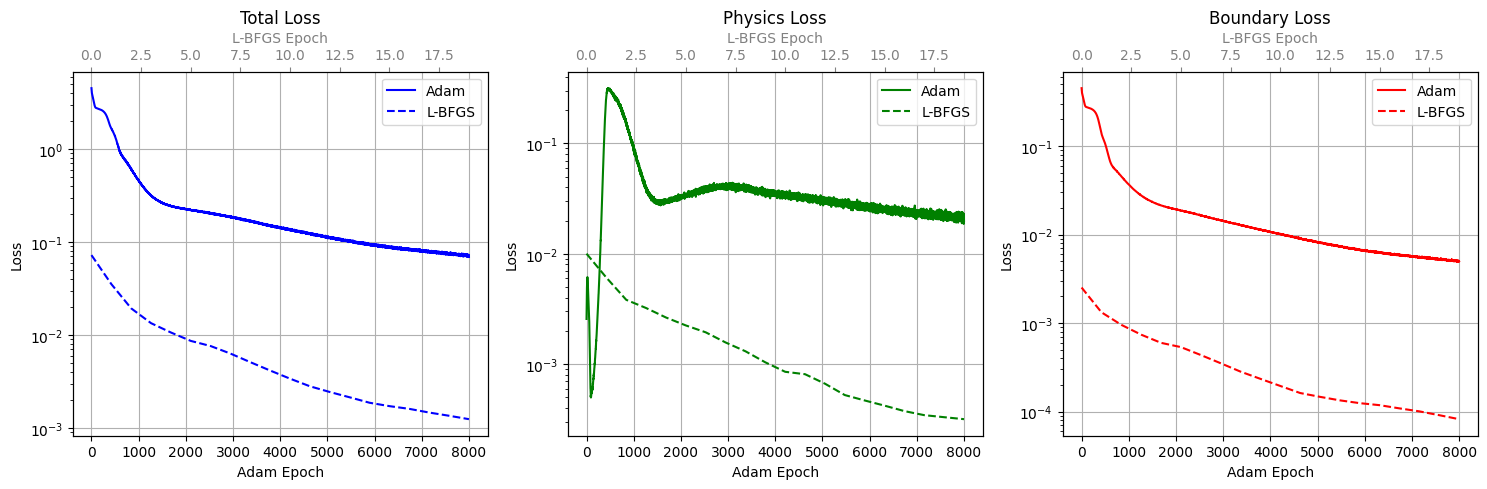

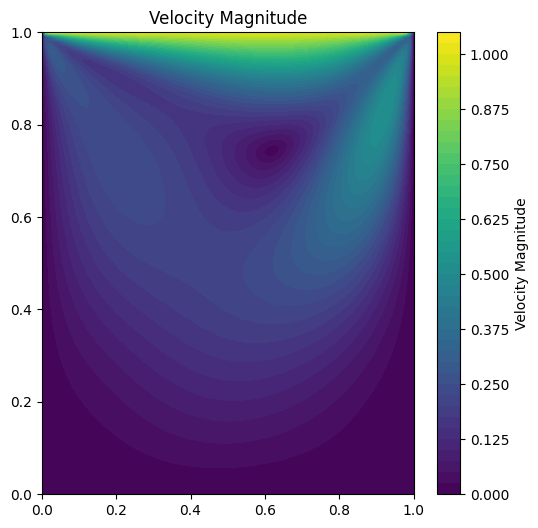

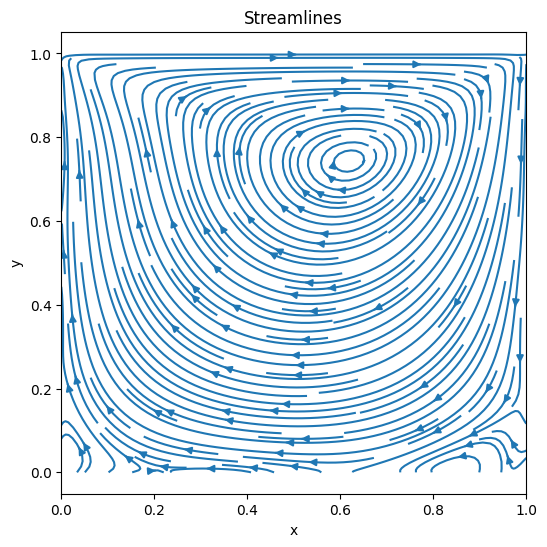

Found minimum velocity of 0.008777 at index (np.int64(74), np.int64(62))
Predicted Center: (0.6263, 0.7475)
Benchmark Center: (0.6172, 0.7344)
Distance Error: 0.01591


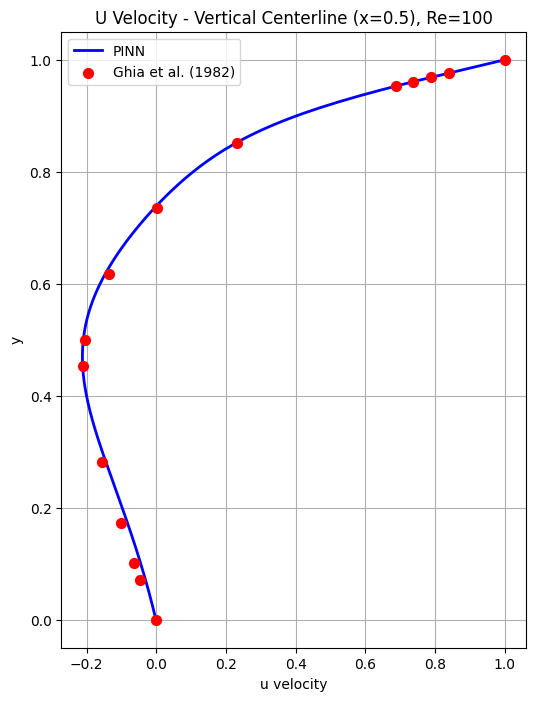

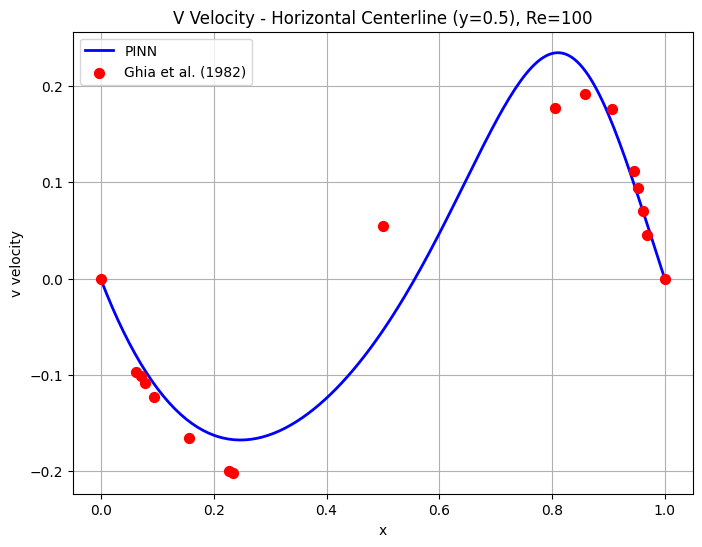

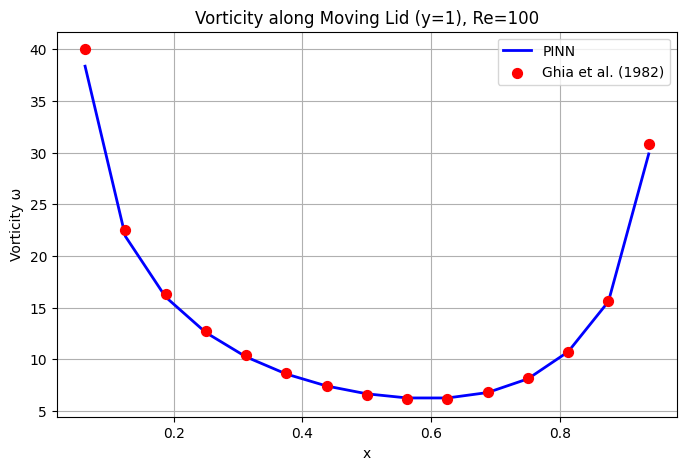

In [12]:
# POST-PROCESSING

# Create grid
nx, ny = 100, 100
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)

X, Y = np.meshgrid(x, y)

# Flatten and convert to tensor (IMPORTANT: send to device)
XY = np.hstack((X.flatten()[:, None], Y.flatten()[:, None]))
XY_tensor = torch.tensor(XY, dtype=torch.float32, device=device)

model.eval()

with torch.no_grad():
    u_pred, v_pred, p_pred = model(
        XY_tensor[:, 0:1],
        XY_tensor[:, 1:2]
    )

# Correct reshape
u = u_pred.cpu().numpy().reshape(ny, nx)
v = v_pred.cpu().numpy().reshape(ny, nx)
p = p_pred.cpu().numpy().reshape(ny, nx)

# Subsample step (take every 5th or 10th point)
step = 5  # try 5 or 10 for fewer arrows

adam_epochs = 8000
lbfgs_epochs = 20

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, key, color, title in zip(axes, 
                                  ['total', 'physics', 'boundary'],
                                  ['blue', 'green', 'red'],
                                  ['Total Loss', 'Physics Loss', 'Boundary Loss']):
    # Adam part
    line_adam, = ax.plot(range(adam_epochs), history[key][:adam_epochs], 
                         color=color, label='Adam')
    
    # L-BFGS part on secondary x-axis
    ax2 = ax.twiny()
    line_lbfgs, = ax2.plot(range(lbfgs_epochs), history[key][adam_epochs:], 
                           color=color, linestyle='--', label='L-BFGS')
    ax2.set_xlabel('L-BFGS Epoch', color='gray')
    ax2.tick_params(axis='x', colors='gray')
    
    ax.set_yscale('log')
    ax.set_xlabel('Adam Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(title)
    ax.grid(True)
    
    # Combine handles from both axes for legend
    ax.legend(handles=[line_adam, line_lbfgs], loc='upper right')

plt.tight_layout()
plt.show()

# Velocity magnitude
velocity_mag = np.sqrt(u**2 + v**2)

plt.figure(figsize=(6,6))
plt.contourf(X, Y, velocity_mag, levels=50)
plt.colorbar(label="Velocity Magnitude")
plt.title("Velocity Magnitude")
plt.show()

plt.figure(figsize=(6,6))
plt.streamplot(X, Y, u, v, density=2)
plt.title("Streamlines")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

def find_vortex_center_debug(X, Y, u, v):
    # Ensure everything is a numpy array
    u_np = np.array(u)
    v_np = np.array(v)
    
    vel_mag = np.sqrt(u_np**2 + v_np**2)
    
    # 1. Focus only on the upper-right quadrant where the Re=100 eye lives
    # This prevents picking up zero-velocity points at the bottom/side walls
    mask = (X > 0.4) & (X < 0.8) & (Y > 0.5) & (Y < 0.9)
    
    # 2. Check if the mask actually captured any points
    if not np.any(mask):
        return None, None, "Mask Error: No points found in range"

    # 3. Set everything outside the mask to a very high velocity
    interior_vel = np.copy(vel_mag)
    interior_vel[~mask] = 10.0  # ~mask means 'not in mask'
    
    # 4. Find the minimum
    min_idx = np.unravel_index(np.argmin(interior_vel), interior_vel.shape)
    
    v_x = X[min_idx]
    v_y = Y[min_idx]
    
    print(f"Found minimum velocity of {interior_vel[min_idx]:.6f} at index {min_idx}")
    return v_x, v_y, None

# Run the debug version
v_x, v_y, err = find_vortex_center_debug(X, Y, u, v)

if err:
    print(err)
else:
    benchmark_x, benchmark_y = 0.6172, 0.7344
    print(f"Predicted Center: ({v_x:.4f}, {v_y:.4f})")
    print(f"Benchmark Center: ({benchmark_x:.4f}, {benchmark_y:.4f})")
    dist = np.sqrt((v_x - benchmark_x)**2 + (v_y - benchmark_y)**2)
    print(f"Distance Error: {dist:.5f}")

# Ghia Re=100 data
ghia_y = [1.0000, 0.9766, 0.9688, 0.9609, 0.9531, 0.8516, 0.7344, 
          0.6172, 0.5000, 0.4531, 0.2813, 0.1719, 0.1016, 0.0703, 0.0000]
ghia_u = [1.0000, 0.8412, 0.7887, 0.7372, 0.6872, 0.2315, 0.0033, 
          -0.1364, -0.2058, -0.2109, -0.1566, -0.1015, -0.0643, -0.0478, 0.0000]

# PINN centerline prediction
y_center = torch.linspace(0, 1, 200).unsqueeze(1).to(device)
x_center = torch.ones_like(y_center) * 0.5

with torch.no_grad():
    u_center, _, _ = model(x_center, y_center)

u_center_np = u_center.cpu().numpy()
y_center_np = y_center.cpu().numpy()

# Plot
plt.figure(figsize=(6, 8))
plt.plot(u_center_np, y_center_np, 'b-', linewidth=2, label='PINN')
plt.scatter(ghia_u, ghia_y, color='red', s=50, zorder=5, label='Ghia et al. (1982)')
plt.xlabel('u velocity')
plt.ylabel('y')
plt.title('U Velocity - Vertical Centerline (x=0.5), Re=100')
plt.legend()
plt.grid(True)
plt.show()

# Ghia Re=100 v velocity along horizontal centerline (y=0.5)
ghia_x = [0.0000, 0.0625, 0.0703, 0.0781, 0.0938, 0.1563, 
          0.2266, 0.2344, 0.5000, 0.8047, 0.8594, 0.9063, 
          0.9453, 0.9531, 0.9609, 0.9688, 1.0000]
ghia_v = [0.0000, -0.0973, -0.1009, -0.1089, -0.1232, -0.1655,
          -0.1993, -0.2016, 0.0545, 0.1776, 0.1919, 0.1763,
          0.1121, 0.0941, 0.0703, 0.0451, 0.0000]

x_horiz = torch.linspace(0, 1, 200).unsqueeze(1).to(device)
y_horiz = torch.ones_like(x_horiz) * 0.5

with torch.no_grad():
    _, v_horiz, _ = model(x_horiz, y_horiz)

plt.figure(figsize=(8, 6))
plt.plot(x_horiz.cpu().numpy(), -v_horiz.cpu().numpy(), 'b-', linewidth=2, label='PINN')
plt.scatter(ghia_x, ghia_v, color='red', s=50, zorder=5, label='Ghia et al. (1982)')
plt.xlabel('x')
plt.ylabel('v velocity')
plt.title('V Velocity - Horizontal Centerline (y=0.5), Re=100')
plt.legend()
plt.grid(True)
plt.show()

# Ghia vorticity along moving lid (y=1) for Re=100
ghia_x_vort = [0.0625, 0.1250, 0.1875, 0.2500, 0.3125, 0.3750, 
               0.4375, 0.5000, 0.5625, 0.6250, 0.6875, 0.7500, 
               0.8125, 0.8750, 0.9375]
ghia_vort = [40.0110, 22.5378, 16.2862, 12.7844, 10.4199, 8.69628,
             7.43218, 6.57451, 6.13973, 6.18946, 6.82674, 8.22110,
             10.7414, 15.6591, 30.7923]

# Compute vorticity along lid (y=1)
x_lid = torch.tensor(ghia_x_vort, dtype=torch.float32).unsqueeze(1).to(device)
y_lid = torch.ones_like(x_lid)
x_lid.requires_grad_(True)
y_lid.requires_grad_(True)

u_lid, v_lid, _ = model(x_lid, y_lid)

v_x = torch.autograd.grad(v_lid, x_lid, grad_outputs=torch.ones_like(v_lid), create_graph=True)[0]
u_y = torch.autograd.grad(u_lid, y_lid, grad_outputs=torch.ones_like(u_lid), create_graph=True)[0]

vorticity_lid = (v_x - u_y).detach().cpu().numpy()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(ghia_x_vort, -vorticity_lid, 'b-', linewidth=2, label='PINN')
plt.scatter(ghia_x_vort, ghia_vort, color='red', s=50, zorder=5, label='Ghia et al. (1982)')
plt.xlabel('x')
plt.ylabel('Vorticity ω')
plt.title('Vorticity along Moving Lid (y=1), Re=100')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
torch.save({
    'model_state_dict': model.state_dict(),
    'history': history
}, "pinn_full.pth")